## COL funtional visualization 012025 & 032024 reads

samples have been run through humann3 and identified genefamilies merged into 1 tsv (see  COL_functional_analysis_012025_032024.ipnyb)

In [1]:
#load libraries (not sure I need all these, but just in case)
library(tidyverse)
library(vegan)
library(phyloseq)
library(ggplot2)
library(RColorBrewer)
library(DESeq2)
library(dplyr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: permute

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following obj

In [2]:
getwd()

[1] "/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL"

In [2]:
setwd("/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL/humann3_functional_analysis_032024_012025/")

In [5]:
genes = read.csv("all_but_0125pstr_genefamilies_rxn_cpm_named.csv")

In [6]:
head(genes)

,X..Gene.Family,X012025_COL_SAN_T5_568_OFAV_S1_comb_kraken_filtered_Abundance.CPM,X012025_COL_SAN_T5_569_DLAB_S2_comb_kraken_filtered_Abundance.CPM,X012025_COL_SAN_T5_570_DLAB_S3_comb_kraken_filtered_Abundance.CPM,X012025_COL_SAN_T5_571_DLAB_S4_comb_kraken_filtered_Abundance.CPM,X012025_COL_SAN_T5_572_OFAV_S5_comb_kraken_filtered_Abundance.CPM,X012025_COL_SAN_T5_574_MCAV_S7_comb_kraken_filtered_Abundance.CPM,X012025_COL_SAN_T5_575_DLAB_S8_comb_kraken_filtered_Abundance.CPM,X012025_COL_SAN_T5_578_MCAV_S11_comb_kraken_filtered_Abundance.CPM,X012025_COL_SAN_T5_579_DLAB_S12_comb_kraken_filtered_Abundance.CPM,⋯,X032024_COL_SAN_T5_150_MCAV_S8_comb_kraken_filtered_Abundance.CPM,X032024_COL_SAN_T5_154_PSTR_S38_comb_kraken_filtered_Abundance.CPM,X032024_COL_SAN_T5_158_DLAB_S15_comb_kraken_filtered_Abundance.CPM,X032024_COL_SAN_T5_159_DLAB_S16_comb_kraken_filtered_Abundance.CPM,X032024_COL_SAN_T5_160_DLAB_S41_comb_kraken_filtered_Abundance.CPM,X032024_COL_SAN_T5_161_DLAB_S42_comb_kraken_filtered_Abundance.CPM,X032024_COL_SAN_T5_162_PSTR_S39_comb_kraken_filtered_Abundance.CPM,X032024_COL_SAN_T5_163_PSTR_S11c_comb_kraken_filtered_Abundance.CPM,X032024_COL_SAN_T5_166_OFAV_S20_comb_kraken_filtered_Abundance.CPM,X032024_COL_SAN_T5_167_OFAV_S21_comb_kraken_filtered_Abundance.CPM
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,UNMAPPED,957318.00,986838.0,952221.00000,949848.00000,958649.0,984650.00,9.270780e+05,984171.00,9.172990e+05,⋯,959563.00000,982681.00,988575.00,989112.00,984053.00,9.471220e+05,979649.000,985808.0,956785.00,960071.00
2,UNGROUPED,42546.16,12621.9,43910.35122,47051.49103,41297.6,15252.76,6.565945e+04,15514.56,7.213278e+04,⋯,36815.96940,17153.79,11315.49,10833.56,15483.37,4.683107e+04,19393.649,14099.5,42969.95,39841.38
3,UNGROUPED|g__Bradyrhizobium.s__Bradyrhizobium_sp_MOS004,0.00,0.0,0.00000,0.00000,0.0,0.00,0.000000e+00,0.00,0.000000e+00,⋯,0.00000,0.00,0.00,0.00,0.00,0.000000e+00,4130.035,0.0,0.00,0.00
4,UNGROUPED|g__Cutibacterium.s__Cutibacterium_acnes,0.00,0.0,0.00000,5620.68763,0.0,0.00,0.000000e+00,0.00,0.000000e+00,⋯,0.00000,0.00,0.00,0.00,0.00,0.000000e+00,0.000,0.0,0.00,0.00
5,UNGROUPED|unclassified,42546.16,12621.9,43910.35122,41430.80339,41297.6,15252.76,6.565945e+04,15514.56,7.213278e+04,⋯,36815.96940,17153.79,11315.49,10833.56,15483.37,4.683107e+04,15263.614,14099.5,42969.95,39841.38
6,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0.00,0.0,1.22774,1.40586,0.0,0.00,1.633278e+00,0.00,8.293820e-01,⋯,1.73995,0.00,0.00,0.00,0.00,3.866170e-01,0.000,0.0,0.00,0.00


In [8]:
#change headers
names(genes)[1] <- "Gene_Family"
names(genes) <- sub("^X", "", names(genes))
names(genes) <- sub("_comb_kraken_filtered_Abundance.CPM","", names(genes))
head(genes)

,Gene_Family,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_578_MCAV_S11,012025_COL_SAN_T5_579_DLAB_S12,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,UNMAPPED,957318.00,986838.0,952221.00000,949848.00000,958649.0,984650.00,9.270780e+05,984171.00,9.172990e+05,⋯,959563.00000,982681.00,988575.00,989112.00,984053.00,9.471220e+05,979649.000,985808.0,956785.00,960071.00
2,UNGROUPED,42546.16,12621.9,43910.35122,47051.49103,41297.6,15252.76,6.565945e+04,15514.56,7.213278e+04,⋯,36815.96940,17153.79,11315.49,10833.56,15483.37,4.683107e+04,19393.649,14099.5,42969.95,39841.38
3,UNGROUPED|g__Bradyrhizobium.s__Bradyrhizobium_sp_MOS004,0.00,0.0,0.00000,0.00000,0.0,0.00,0.000000e+00,0.00,0.000000e+00,⋯,0.00000,0.00,0.00,0.00,0.00,0.000000e+00,4130.035,0.0,0.00,0.00
4,UNGROUPED|g__Cutibacterium.s__Cutibacterium_acnes,0.00,0.0,0.00000,5620.68763,0.0,0.00,0.000000e+00,0.00,0.000000e+00,⋯,0.00000,0.00,0.00,0.00,0.00,0.000000e+00,0.000,0.0,0.00,0.00
5,UNGROUPED|unclassified,42546.16,12621.9,43910.35122,41430.80339,41297.6,15252.76,6.565945e+04,15514.56,7.213278e+04,⋯,36815.96940,17153.79,11315.49,10833.56,15483.37,4.683107e+04,15263.614,14099.5,42969.95,39841.38
6,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0.00,0.0,1.22774,1.40586,0.0,0.00,1.633278e+00,0.00,8.293820e-01,⋯,1.73995,0.00,0.00,0.00,0.00,3.866170e-01,0.000,0.0,0.00,0.00


In [9]:
#remove specific rows
genes_filtered <- genes[!grepl("UNMAPPED|UNGROUPED", genes$Gene_Family), ]
#genes <- genes[!grepl("UNGROUPED", genes$Gene_Family), ]
head(genes_filtered)

,Gene_Family,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_578_MCAV_S11,012025_COL_SAN_T5_579_DLAB_S12,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0,0.00000,1.22774,1.40586,0,0,1.633278,0,0.829382,⋯,1.73995,0,0,0,0,0.386617,0.000000,0,0,0
7,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51]|unclassified,0,0.00000,1.22774,1.40586,0,0,1.633278,0,0.829382,⋯,1.73995,0,0,0,0,0.386617,0.000000,0,0,0
8,1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0,1.21059,0.00000,0.00000,0,0,1.793940,0,0.000000,⋯,0.00000,0,0,0,0,0.805231,0.303034,0,0,0
9,1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127]|unclassified,0,1.21059,0.00000,0.00000,0,0,1.793940,0,0.000000,⋯,0.00000,0,0,0,0,0.805231,0.303034,0,0,0
10,1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0,0.00000,0.00000,0.00000,0,0,0.000000,0,0.000000,⋯,0.00000,0,0,0,0,0.000000,0.000000,0,0,0
11,1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136]|unclassified,0,0.00000,0.00000,0.00000,0,0,0.000000,0,0.000000,⋯,0.00000,0,0,0,0,0.000000,0.000000,0,0,0


In [10]:
#remove the "unclassified" versions 
genes_filtered <- genes_filtered[!grepl("unclassified", genes_filtered$Gene_Family), ]
head(genes_filtered)
dim(genes_filtered)

,Gene_Family,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_578_MCAV_S11,012025_COL_SAN_T5_579_DLAB_S12,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0,0.00000,1.22774,1.40586,0,0,1.633278,0,0.829382,⋯,1.73995,0,0,0,0,0.386617,0.000000,0,0,0
8,1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0,1.21059,0.00000,0.00000,0,0,1.793940,0,0.000000,⋯,0.00000,0,0,0,0,0.805231,0.303034,0,0,0
10,1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0,0.00000,0.00000,0.00000,0,0,0.000000,0,0.000000,⋯,0.00000,0,0,0,0,0.000000,0.000000,0,0,0
12,1.1.1.261-RXN: (expasy) sn-glycerol-1-phosphate dehydrogenase [1.1.1.261],0,0.00000,0.00000,0.00000,0,0,0.000000,0,8.542400,⋯,0.00000,0,0,0,0,2.601460,0.000000,0,0,0
14,1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],0,0.00000,0.00000,0.00000,0,0,0.000000,0,11.418100,⋯,0.00000,0,0,0,0,3.398880,0.000000,0,0,0
16,1.1.1.269-RXN: (expasy) 2-(S)-hydroxypropyl-CoM dehydrogenase [1.1.1.269],0,0.00000,4.48011,6.16647,0,0,1.751480,0,0.526412,⋯,0.00000,0,0,0,0,0.000000,0.000000,0,0,0


[1] 4591   50

In [11]:
#remove rows with "g__Cutibacterium.s__Cutibacterium_acnes" and "g__Bradyrhizobium.s__Bradyrhizobium_sp_MOS004"
genes_filtered <- genes_filtered[!grepl("g__Cutibacterium.s__Cutibacterium_acnes|g__Bradyrhizobium.s__Bradyrhizobium_sp_MOS004", genes_filtered$Gene_Family), ]
head(genes_filtered)
dim (genes_filtered)

,Gene_Family,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_578_MCAV_S11,012025_COL_SAN_T5_579_DLAB_S12,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0,0.00000,1.22774,1.40586,0,0,1.633278,0,0.829382,⋯,1.73995,0,0,0,0,0.386617,0.000000,0,0,0
8,1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0,1.21059,0.00000,0.00000,0,0,1.793940,0,0.000000,⋯,0.00000,0,0,0,0,0.805231,0.303034,0,0,0
10,1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0,0.00000,0.00000,0.00000,0,0,0.000000,0,0.000000,⋯,0.00000,0,0,0,0,0.000000,0.000000,0,0,0
12,1.1.1.261-RXN: (expasy) sn-glycerol-1-phosphate dehydrogenase [1.1.1.261],0,0.00000,0.00000,0.00000,0,0,0.000000,0,8.542400,⋯,0.00000,0,0,0,0,2.601460,0.000000,0,0,0
14,1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],0,0.00000,0.00000,0.00000,0,0,0.000000,0,11.418100,⋯,0.00000,0,0,0,0,3.398880,0.000000,0,0,0
16,1.1.1.269-RXN: (expasy) 2-(S)-hydroxypropyl-CoM dehydrogenase [1.1.1.269],0,0.00000,4.48011,6.16647,0,0,1.751480,0,0.526412,⋯,0.00000,0,0,0,0,0.000000,0.000000,0,0,0


[1] 2902   50

In [12]:
#just checking to see
write.csv(as.data.frame(genes_filtered), file= "genes_filtered.csv")

In [13]:
#reorder columns from list file (just concatenated the IDs together in the order I wanted
#also included Gene_Family first, to keep that the first column
column_list <- readLines("COL_column_order.txt")
genes_filtered_reordered <- genes_filtered[, column_list]
head(genes_filtered_reordered)

,Gene_Family,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,⋯,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_579_DLAB_S12,012025_COL_SAN_T5_586_DLAB_S19,032024_COL_SAN_T5_144_PSTR_S9,032024_COL_SAN_T5_147_PSTR_S10,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_162_PSTR_S39
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0,0,0,0,0,0,0,0,0,⋯,1.22774,1.40586,1.633278,0.829382,0,0,0.000000,0,0,0.000000
8,1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0,0,0,0,0,0,0,0,0,⋯,0.00000,0.00000,1.793940,0.000000,0,0,0.615957,0,0,0.303034
10,1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0,0,0,0,0,0,0,0,0,⋯,0.00000,0.00000,0.000000,0.000000,0,0,0.000000,0,0,0.000000
12,1.1.1.261-RXN: (expasy) sn-glycerol-1-phosphate dehydrogenase [1.1.1.261],0,0,0,0,0,0,0,0,0,⋯,0.00000,0.00000,0.000000,8.542400,0,0,0.000000,0,0,0.000000
14,1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],0,0,0,0,0,0,0,0,0,⋯,0.00000,0.00000,0.000000,11.418100,0,0,0.000000,0,0,0.000000
16,1.1.1.269-RXN: (expasy) 2-(S)-hydroxypropyl-CoM dehydrogenase [1.1.1.269],0,0,0,0,0,0,0,0,0,⋯,4.48011,6.16647,1.751480,0.526412,0,0,0.000000,0,0,0.000000


In [14]:
# make the index the gene_family
row.names(genes_filtered_reordered) <- genes_filtered_reordered$Gene_Family
genes_filtered_reordered$Gene_Family <- NULL
head(genes_filtered_reordered)

,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,012025_COL_SAN_T5_585_OFAV_S18,⋯,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_579_DLAB_S12,012025_COL_SAN_T5_586_DLAB_S19,032024_COL_SAN_T5_144_PSTR_S9,032024_COL_SAN_T5_147_PSTR_S10,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_162_PSTR_S39
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0,0,0,0,0,0,0,0,0,0,⋯,1.22774,1.40586,1.633278,0.829382,0,0,0.000000,0,0,0.000000
1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0,0,0,0,0,0,0,0,0,0,⋯,0.00000,0.00000,1.793940,0.000000,0,0,0.615957,0,0,0.303034
1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0,0,0,0,0,0,0,0,0,0,⋯,0.00000,0.00000,0.000000,0.000000,0,0,0.000000,0,0,0.000000
1.1.1.261-RXN: (expasy) sn-glycerol-1-phosphate dehydrogenase [1.1.1.261],0,0,0,0,0,0,0,0,0,0,⋯,0.00000,0.00000,0.000000,8.542400,0,0,0.000000,0,0,0.000000
1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],0,0,0,0,0,0,0,0,0,0,⋯,0.00000,0.00000,0.000000,11.418100,0,0,0.000000,0,0,0.000000
1.1.1.269-RXN: (expasy) 2-(S)-hydroxypropyl-CoM dehydrogenase [1.1.1.269],0,0,0,0,0,0,0,0,0,0,⋯,4.48011,6.16647,1.751480,0.526412,0,0,0.000000,0,0,0.000000


In [15]:
#transpose - want samples as rows
genes_filtered_reordered_t <- t(genes_filtered_reordered)
head(genes_filtered_reordered_t)

,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],1.1.1.261-RXN: (expasy) sn-glycerol-1-phosphate dehydrogenase [1.1.1.261],1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],1.1.1.269-RXN: (expasy) 2-(S)-hydroxypropyl-CoM dehydrogenase [1.1.1.269],1.1.1.271-RXN: (expasy) GDP-L-fucose synthase [1.1.1.271],"1.1.1.274-RXN: (expasy) 2,5-didehydrogluconate reductase (2-dehydro-D-gluconate-forming) [1.1.1.274]",1.1.1.291-RXN: (expasy) 2-hydroxymethylglutarate dehydrogenase [1.1.1.291],"1.1.1.292-RXN: (expasy) 1,5-anhydro-D-fructose reductase (1,5-anhydro-D-mannitol-forming) [1.1.1.292]",⋯,UROGENDECARBOX-RXN: (expasy) Uroporphyrinogen decarboxylase [4.1.1.37],UROGENIIISYN-RXN: (expasy) Uroporphyrinogen-III synthase [4.2.1.75],URPHOS-RXN: (expasy) AMBIGUOUS [2.4.2.2; 2.4.2.3],VALINE--TRNA-LIGASE-RXN: (expasy) Valine--tRNA ligase [6.1.1.9],VALINE-PYRUVATE-AMINOTRANSFER-RXN: (expasy) Valine--pyruvate transaminase [2.6.1.66],XANPRIBOSYLTRAN-RXN: (expasy) Xanthine phosphoribosyltransferase [2.4.2.22],XANTHOSINEPHOSPHORY-RXN: (expasy) Purine-nucleoside phosphorylase [2.4.2.1],XMPXAN-RXN: (expasy) 5'-nucleotidase [3.1.3.5],XYLISOM-RXN: (expasy) Xylose isomerase [5.3.1.5],XYLULOKIN-RXN: (expasy) Xylulokinase [2.7.1.17]
032024_COL_SAN_T5_139_OFAV_S17,0,0,0,0,0,0,0,1.03453,0,0,⋯,0.000000,0,0,0.000000,0,0,0,0,0.000000,0.000000
032024_COL_SAN_T5_140_OFAV_S18c,0,0,0,0,0,0,0,0.00000,0,0,⋯,0.000000,0,0,0.000000,0,0,0,0,0.000000,0.000000
032024_COL_SAN_T5_141_OFAV_S19,0,0,0,0,0,0,0,0.00000,0,0,⋯,0.000000,0,0,0.000000,0,0,0,0,0.000000,0.000000
032024_COL_SAN_T5_166_OFAV_S20,0,0,0,0,0,0,0,0.00000,0,0,⋯,1.969886,0,0,0.000000,0,0,0,0,0.000000,0.694876
032024_COL_SAN_T5_167_OFAV_S21,0,0,0,0,0,0,0,0.00000,0,0,⋯,0.000000,0,0,0.000000,0,0,0,0,0.000000,0.000000
012025_COL_SAN_T5_568_OFAV_S1,0,0,0,0,0,0,0,0.00000,0,0,⋯,0.643074,0,0,0.284085,0,0,0,0,0.372796,0.000000


In [16]:
#convert to matrix
genes_filtered_reordered_t=as.matrix(genes_filtered_reordered_t)
head(genes_filtered_reordered_t)

,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],1.1.1.261-RXN: (expasy) sn-glycerol-1-phosphate dehydrogenase [1.1.1.261],1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],1.1.1.269-RXN: (expasy) 2-(S)-hydroxypropyl-CoM dehydrogenase [1.1.1.269],1.1.1.271-RXN: (expasy) GDP-L-fucose synthase [1.1.1.271],"1.1.1.274-RXN: (expasy) 2,5-didehydrogluconate reductase (2-dehydro-D-gluconate-forming) [1.1.1.274]",1.1.1.291-RXN: (expasy) 2-hydroxymethylglutarate dehydrogenase [1.1.1.291],"1.1.1.292-RXN: (expasy) 1,5-anhydro-D-fructose reductase (1,5-anhydro-D-mannitol-forming) [1.1.1.292]",⋯,UROGENDECARBOX-RXN: (expasy) Uroporphyrinogen decarboxylase [4.1.1.37],UROGENIIISYN-RXN: (expasy) Uroporphyrinogen-III synthase [4.2.1.75],URPHOS-RXN: (expasy) AMBIGUOUS [2.4.2.2; 2.4.2.3],VALINE--TRNA-LIGASE-RXN: (expasy) Valine--tRNA ligase [6.1.1.9],VALINE-PYRUVATE-AMINOTRANSFER-RXN: (expasy) Valine--pyruvate transaminase [2.6.1.66],XANPRIBOSYLTRAN-RXN: (expasy) Xanthine phosphoribosyltransferase [2.4.2.22],XANTHOSINEPHOSPHORY-RXN: (expasy) Purine-nucleoside phosphorylase [2.4.2.1],XMPXAN-RXN: (expasy) 5'-nucleotidase [3.1.3.5],XYLISOM-RXN: (expasy) Xylose isomerase [5.3.1.5],XYLULOKIN-RXN: (expasy) Xylulokinase [2.7.1.17]
032024_COL_SAN_T5_139_OFAV_S17,0,0,0,0,0,0,0,1.03453,0,0,⋯,0.000000,0,0,0.000000,0,0,0,0,0.000000,0.000000
032024_COL_SAN_T5_140_OFAV_S18c,0,0,0,0,0,0,0,0.00000,0,0,⋯,0.000000,0,0,0.000000,0,0,0,0,0.000000,0.000000
032024_COL_SAN_T5_141_OFAV_S19,0,0,0,0,0,0,0,0.00000,0,0,⋯,0.000000,0,0,0.000000,0,0,0,0,0.000000,0.000000
032024_COL_SAN_T5_166_OFAV_S20,0,0,0,0,0,0,0,0.00000,0,0,⋯,1.969886,0,0,0.000000,0,0,0,0,0.000000,0.694876
032024_COL_SAN_T5_167_OFAV_S21,0,0,0,0,0,0,0,0.00000,0,0,⋯,0.000000,0,0,0.000000,0,0,0,0,0.000000,0.000000
012025_COL_SAN_T5_568_OFAV_S1,0,0,0,0,0,0,0,0.00000,0,0,⋯,0.643074,0,0,0.284085,0,0,0,0,0.372796,0.000000


In [28]:
#don't do this way, scroll down to create distance matrix first
set.seed(123)
nmds_ord <- metaMDS(genes_filtered_reordered_t, distance="bray") 

Square root transformation
Wisconsin double standardization
Run 0 stress 0.1709212 
Run 1 stress 0.1731391 
Run 2 stress 0.1699928 
... New best solution
... Procrustes: rmse 0.03947019  max resid 0.1945081 
Run 3 stress 0.1770731 
Run 4 stress 0.1862218 
Run 5 stress 0.1706655 
... Procrustes: rmse 0.03538483  max resid 0.2235406 
Run 6 stress 0.2010429 
Run 7 stress 0.1984072 
Run 8 stress 0.1744762 
Run 9 stress 0.1770433 
Run 10 stress 0.1875574 
Run 11 stress 0.1782592 
Run 12 stress 0.1755942 
Run 13 stress 0.1907719 
Run 14 stress 0.1839261 
Run 15 stress 0.1740552 
Run 16 stress 0.171938 
Run 17 stress 0.1861468 
Run 18 stress 0.1797125 
Run 19 stress 0.1732381 
Run 20 stress 0.1988633 
*** Best solution was not repeated -- monoMDS stopping criteria:
    20: stress ratio > sratmax


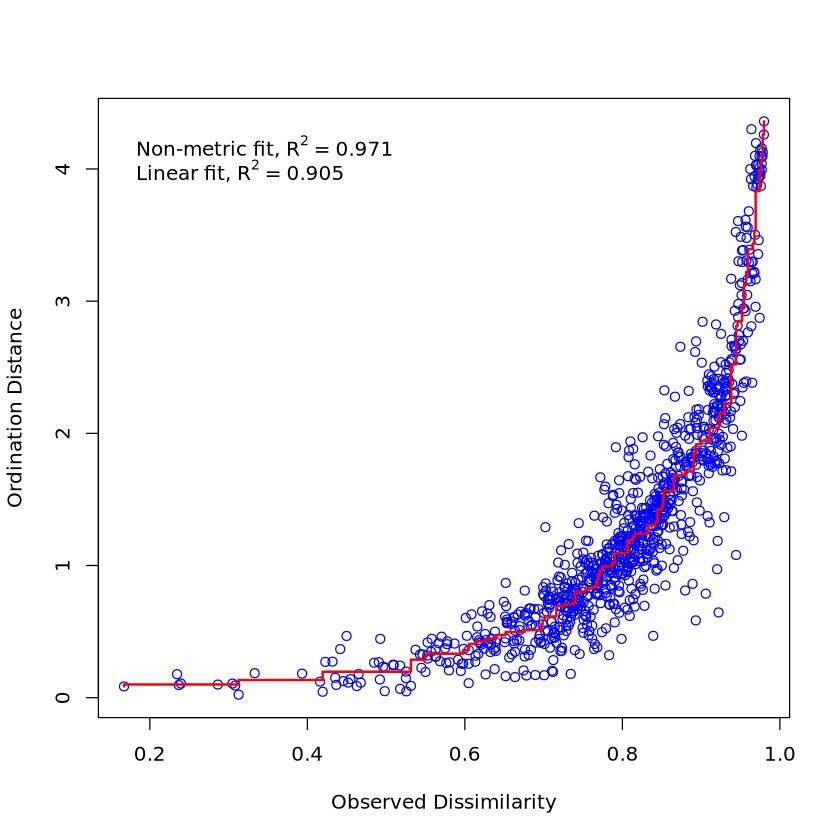

In [29]:
stressplot(nmds_ord)

Run 0 stress 0.1331913 
Run 1 stress 0.1511354 
Run 2 stress 0.1426304 
Run 3 stress 0.1461097 
Run 4 stress 0.1299456 
... New best solution
... Procrustes: rmse 0.04546621  max resid 0.2313077 
Run 5 stress 0.1450156 
Run 6 stress 0.1560936 
Run 7 stress 0.1542751 
Run 8 stress 0.1331915 
Run 9 stress 0.1337994 
Run 10 stress 0.1478534 
Run 11 stress 0.1299456 
... Procrustes: rmse 0.0002421673  max resid 0.001196572 
... Similar to previous best
Run 12 stress 0.1463943 
Run 13 stress 0.1280548 
... New best solution
... Procrustes: rmse 0.03010925  max resid 0.2004653 
Run 14 stress 0.1300268 
Run 15 stress 0.1339189 
Run 16 stress 0.1280548 
... Procrustes: rmse 0.0003002998  max resid 0.001278705 
... Similar to previous best
Run 17 stress 0.1464691 
Run 18 stress 0.1514794 
Run 19 stress 0.1280555 
... Procrustes: rmse 0.0005115402  max resid 0.002327813 
... Similar to previous best
Run 20 stress 0.1419706 
*** Best solution repeated 2 times


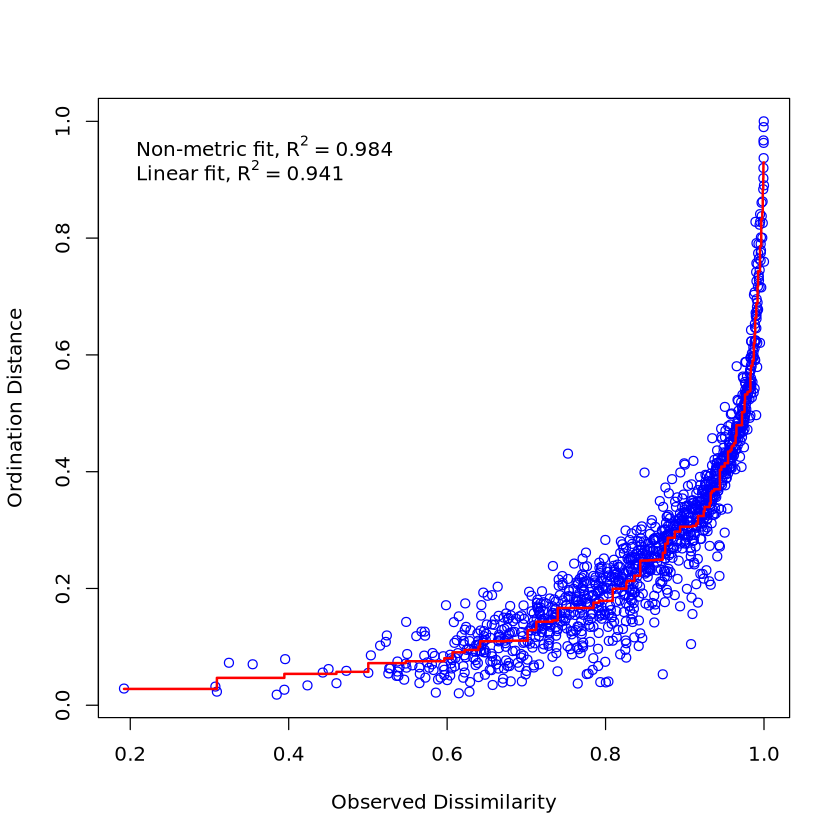

In [17]:
#created the distance matrix first and then ran metaMDS
bray_dist<- vegdist(genes_filtered_reordered_t, "bray") 
bray<-as.matrix(bray_dist)
write.csv(bray, "bray_distance_matrix.csv")
set.seed(124)
MDS<- metaMDS(bray)
stressplot(MDS)

In [18]:
nmds_scores <- scores(MDS, choices=c(1,2))

In [21]:
write.csv(nmds_scores, file= "nmds_scores_all_but_0125_pstr_genefamilies.csv")

In [25]:
plot_scores <- read.csv("nmds_plot_all_but_0125_pstr_genefamilies.csv", header=T)

In [23]:
options(repr.plot.width=20, repr.plot.height=15)

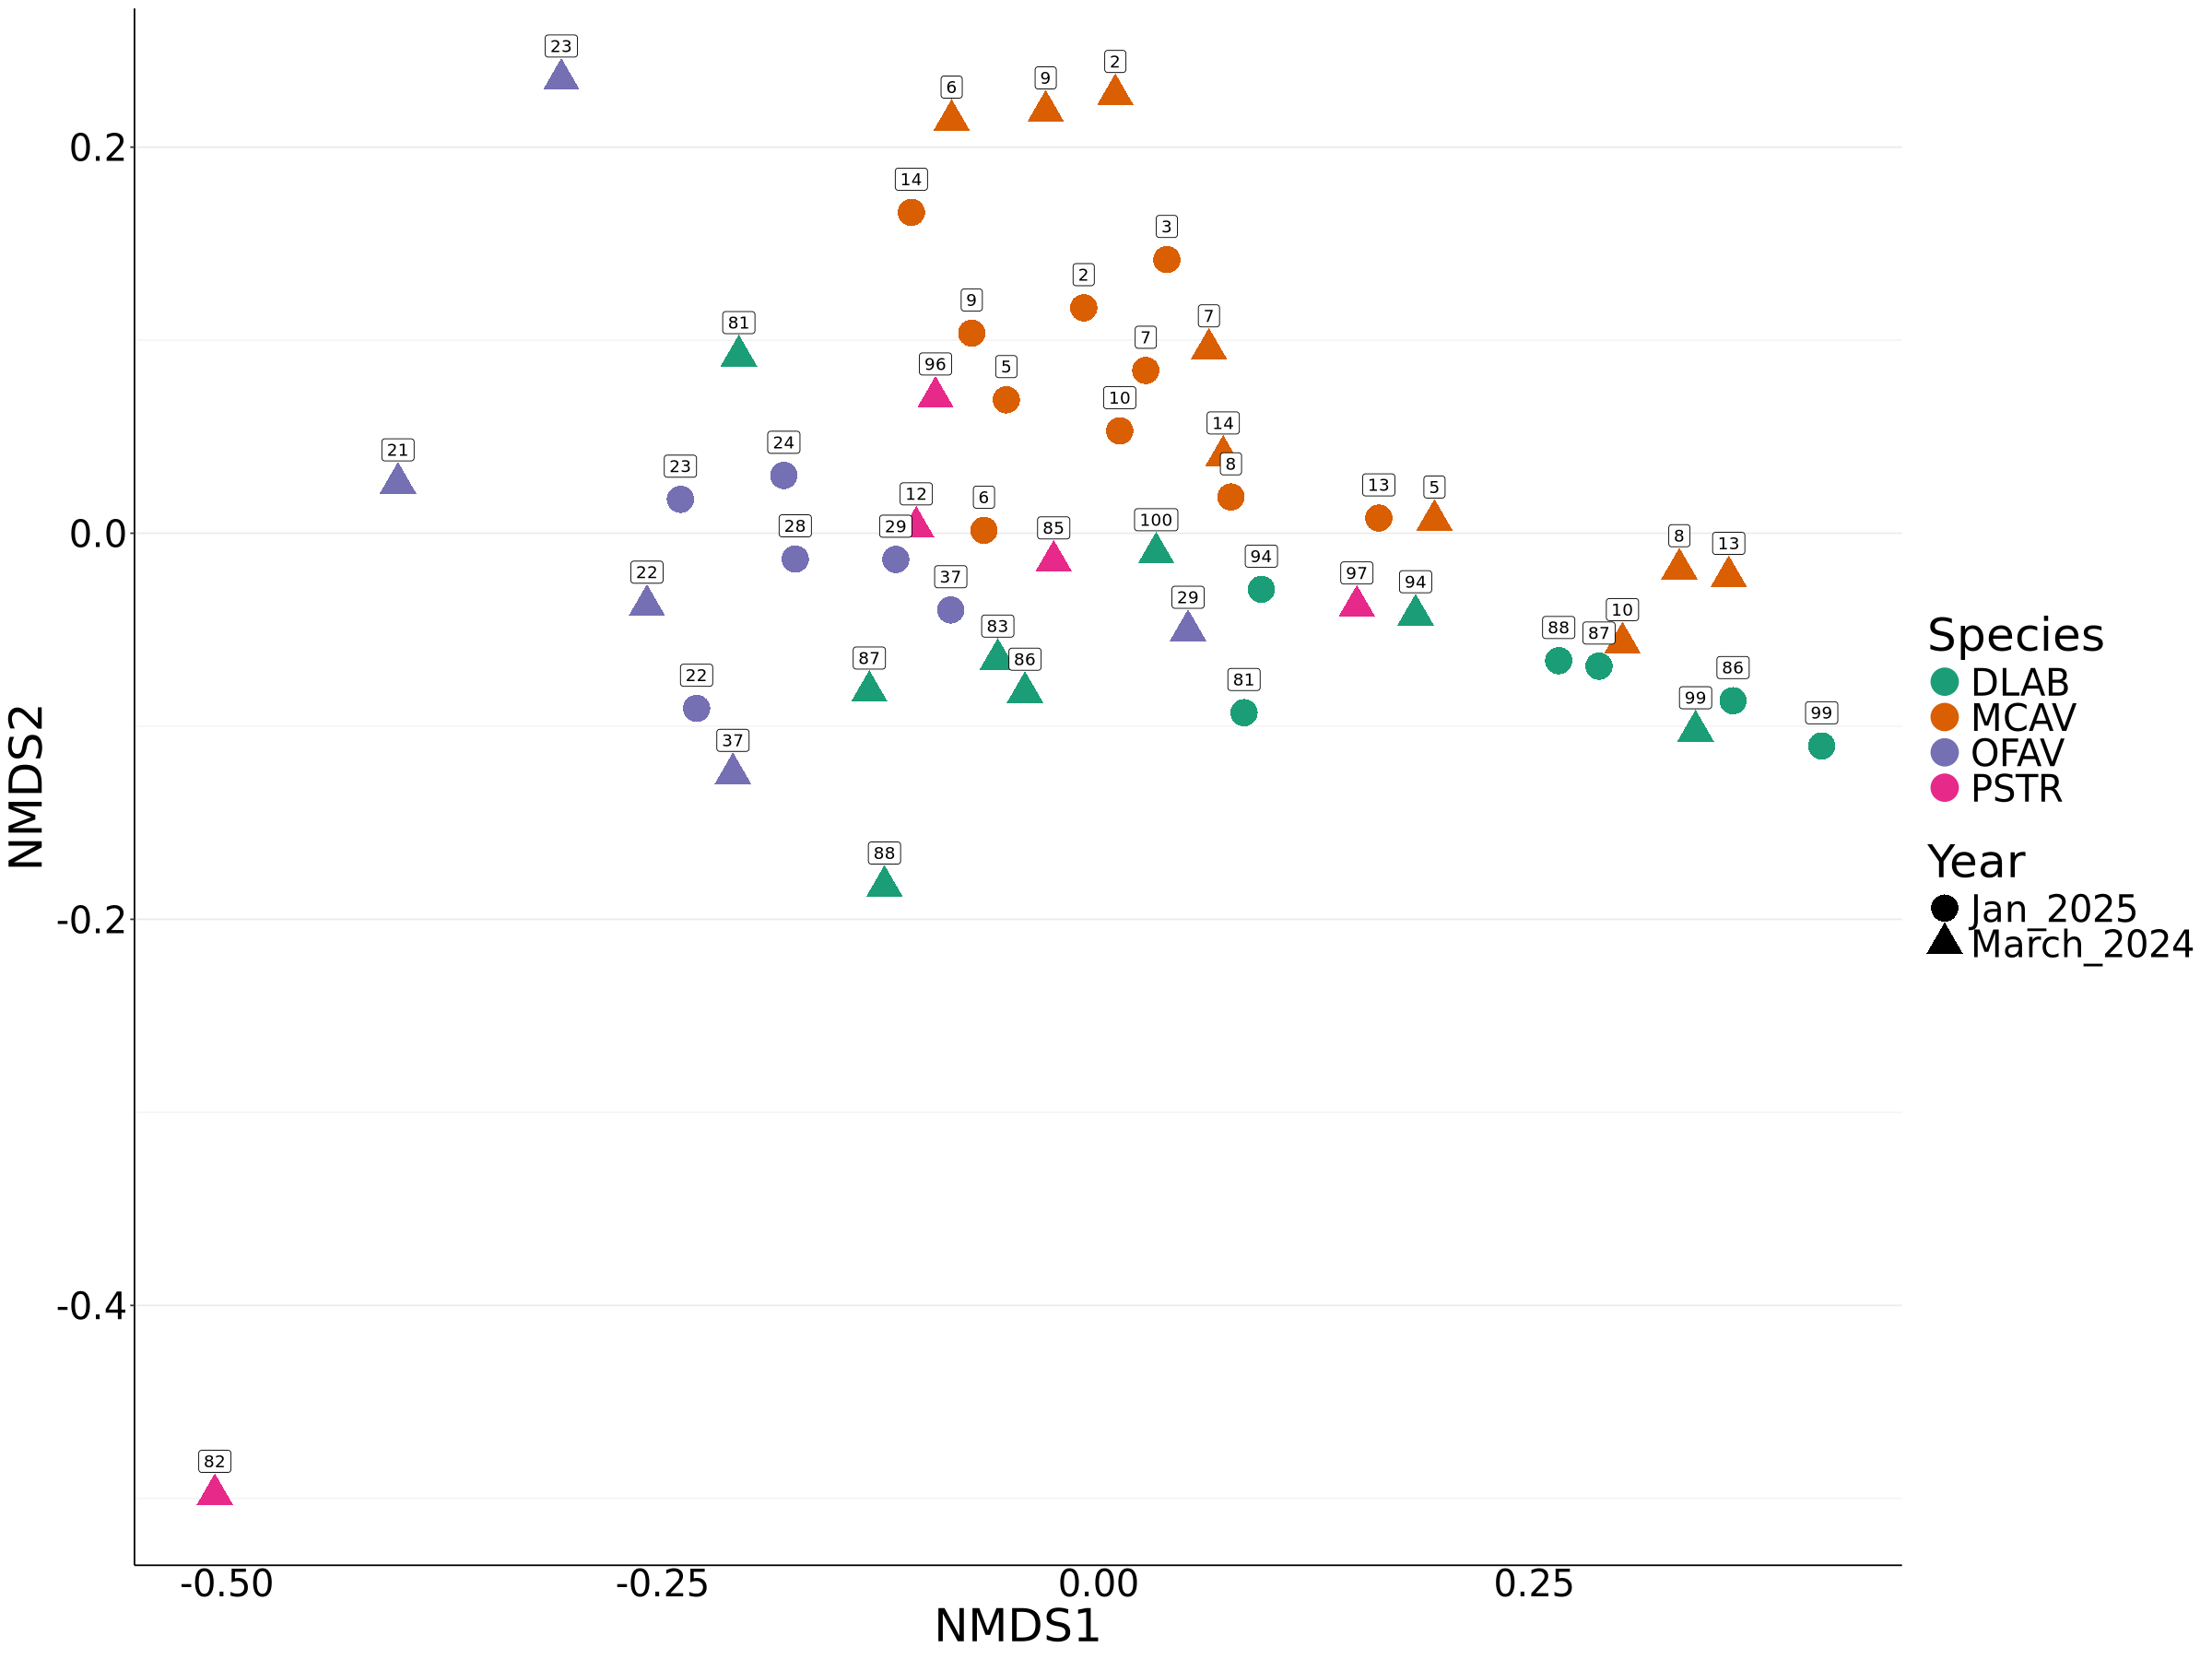

In [28]:
plot <- ggplot(data=plot_scores, aes(x=NMDS1,y=NMDS2, shape= Year, color = Species)) + 
  geom_point(size=8) + scale_color_brewer(palette = "Dark2") +
  geom_label(aes(label = Tag), vjust = -1, color = "black") +
  xlab("NMDS1") + ylab ("NMDS2") +
  theme_bw() +
  theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 30))
    
plot